## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


#### Problem Statement 

Agricultural activities are influenced by seasonal variations in environmental conditions, 
farming practices, resource availability and market conditions. As a result, agricultural 
performance may differ from one season to another. 
However, raw agricultural data does not clearly explain how agricultural performance changes 
across seasons or what patterns can be observed in different seasonal conditions. 
The problem is to analyze the given agricultural dataset and investigate seasonal differences 
in agricultural performance by identifying meaningful patterns, trends, relationships and 
variations within the available data. 

#### Data cleaning and Explotary data analysis

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
path = r"D:\OneDrive\Desktop\vi internship\major project\analysis_data.csv"
df = pd.read_csv(path)

In [80]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [81]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [82]:
# Shape of the data

print(df.shape[0] , "Rows")
print(df.shape[1] , "columns")

4000 Rows
28 columns


In [83]:
# checking the duplicates
df.duplicated().sum()

np.int64(0)

* No Duplicates Found

In [84]:
# checking for null values percentage
df.isnull().sum()/df.shape[0] * 100

Farm_ID                          0.0
State                            0.0
District                         0.0
Crop                             0.0
Season                           0.0
Farm_Area_Hectares               0.0
Rainfall_mm                      1.2
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
Soil_pH                          0.0
Soil_Moisture_pct                1.0
Nitrogen_kg_ha                   0.0
Phosphorus_kg_ha                 0.0
Potassium_kg_ha                  0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Yield_Tonnes_Ha                  0.8
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [87]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [88]:
# Filling the null values with median values of the respective columns
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

In [89]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

# Key Questions

1. How does agricultural performance vary across seasons?

2. What major seasonal patterns can be observed?

3. Which characteristics change between seasons?

4. Are there noticeable variations in resource usage across seasons?

5. Are there relationships between seasonal environmental conditions and agricultural performance?

6. How do economic outcomes vary across seasons?

7. Are some seasonal patterns consistent across different regions or categories?

8. which irrigation type has more yield

9. Are there unusual or unexpected seasonal patterns?

10. What insights can be derived from the observed seasonal differences?

1. How does agricultural performance vary across seasons?

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


<Axes: xlabel='Season'>

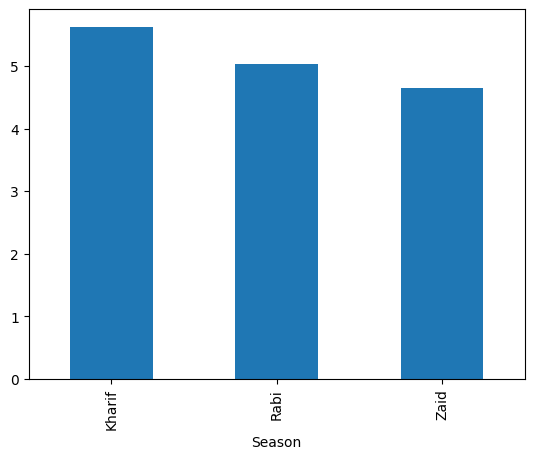

In [101]:
perfomance = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
print(perfomance)
perfomance.plot(kind="bar")

2. What major seasonal patterns can be observed?

In [92]:
seasonal_summary = df.groupby("Season").agg({
	"Yield_Tonnes_Ha": "mean",
	"Rainfall_mm": "mean",
	"Avg_Temperature_C": "mean",
	"Soil_Moisture_pct": "mean",
	"Water_Used_m3": "mean",
	"Profit_INR": "mean",
	"Seed_Quality_Score": "mean",
}).reindex(["Kharif", "Rabi", "Zaid"])

print(seasonal_summary.round(2))

        Yield_Tonnes_Ha  Rainfall_mm  Avg_Temperature_C  Soil_Moisture_pct  \
Season                                                                       
Kharif             5.63       849.20              28.45              31.15   
Rabi               5.04       437.62              23.49              24.07   
Zaid               4.64       304.65              31.04              19.28   

        Water_Used_m3  Profit_INR  Seed_Quality_Score  
Season                                                 
Kharif        6102.20   178914.65                0.82  
Rabi          5846.99    87689.47                0.83  
Zaid          6419.89   -24804.82                0.82  


* Kharif season has the highest average yield and profit among the three seasons.
* Zaid season has the lowest average yield and shows a negative average profit.
* Kharif receives the highest average rainfall and has the highest soil moisture.
* Zaid has the highest average temperature and water usage.
* Overall, Kharif shows better agricultural performance, while Zaid appears less profitable based on the seasonal averages.

3. Which characteristics change between seasons?

In [93]:
changes = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Soil_Moisture_pct": "mean",
    "Water_Used_m3": "mean",
    "Profit_INR": "mean",
    "Seed_Quality_Score": "mean"
}).reindex(["Kharif", "Rabi", "Zaid"])

print(changes.round(2))

        Yield_Tonnes_Ha  Rainfall_mm  Avg_Temperature_C  Soil_Moisture_pct  \
Season                                                                       
Kharif             5.63       849.20              28.45              31.15   
Rabi               5.04       437.62              23.49              24.07   
Zaid               4.64       304.65              31.04              19.28   

        Water_Used_m3  Profit_INR  Seed_Quality_Score  
Season                                                 
Kharif        6102.20   178914.65                0.82  
Rabi          5846.99    87689.47                0.83  
Zaid          6419.89   -24804.82                0.82  


* On the Analysis i Observed that there are less yield in the zaid season as compared to the remaining seasons
* In the Season of zaid less rainfall and the high temperature as compared to other season and there is no profit in the season of zaid 
* kharif season is best for the farming 

4. Are there noticeable variations in resource usage across seasons?

In [94]:
resource = df.groupby("Season").agg({
"Fertilizer_kg_ha":"mean",
"Pesticide_Litre_ha":"mean",
"Water_Used_m3":"mean"
}).reindex(["Kharif", "Rabi", "Zaid"])

print(resource.round(2))

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3
Season                                                     
Kharif            187.08                5.08        6102.20
Rabi              185.41                5.02        5846.99
Zaid              184.64                5.17        6419.89


* In analysis i observed that there are no flucations in the seasonal wise resource used
* But in the rabi season used less water 

5. Are there relationships between seasonal environmental conditions and agricultural performance?

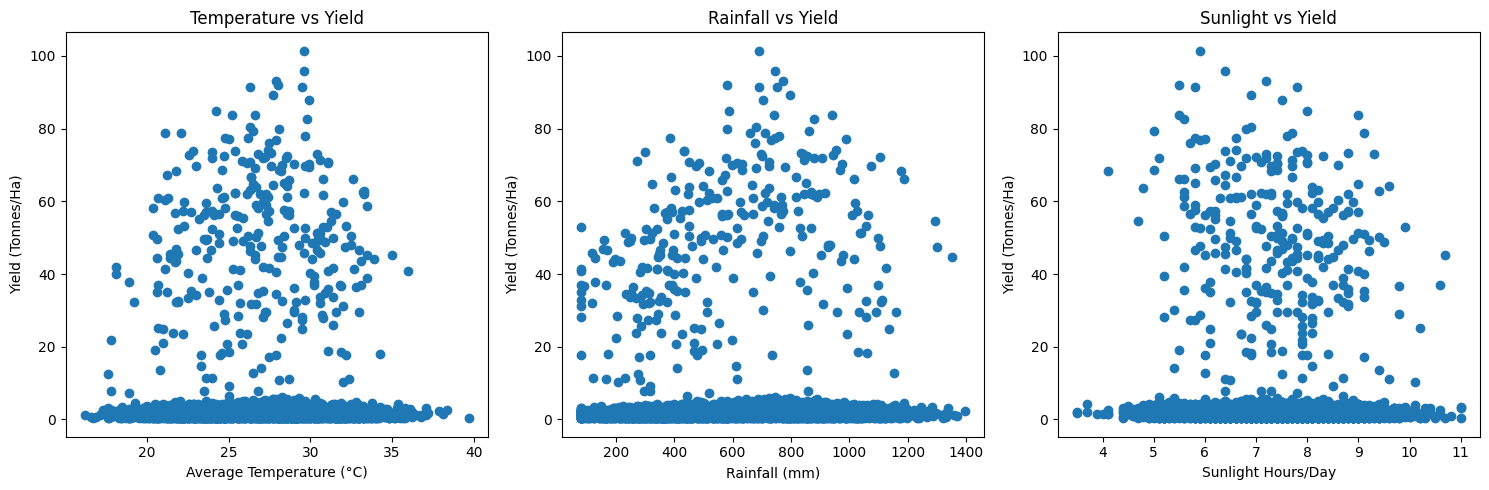

In [95]:
plt.figure(figsize=(15, 5))

# Temperature vs Yield
plt.subplot(1, 3, 1)
plt.scatter(df["Avg_Temperature_C"], df["Yield_Tonnes_Ha"])
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Temperature vs Yield")

# Rainfall vs Yield
plt.subplot(1, 3, 2)
plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"])
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Rainfall vs Yield")

# Sunlight vs Yield
plt.subplot(1, 3, 3)
plt.scatter(df["Sunlight_Hours_Day"], df["Yield_Tonnes_Ha"])
plt.xlabel("Sunlight Hours/Day")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Sunlight vs Yield")

plt.tight_layout()
plt.show()

* Temperature has no clear effect on yield.
* Yield is generally higher with 400–900 mm rainfall.
* Yield is generally higher with 6–9 hours of sunlight.
* Overall, no single environmental factor strongly determines yield.

6. How do economic outcomes vary across seasons?

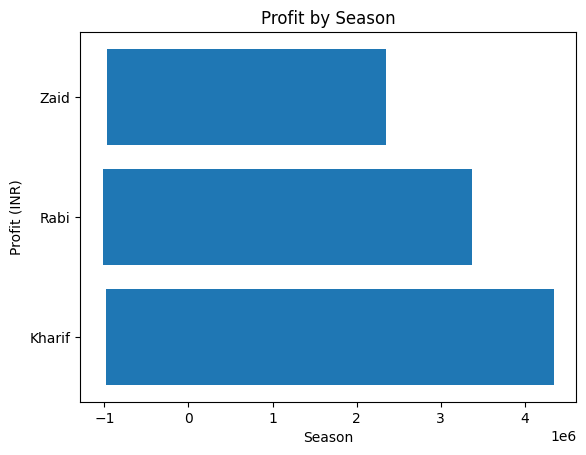

In [96]:
plt.barh(df["Season"], df["Profit_INR"])
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.title("Profit by Season")
plt.show()

* **Kharif** season has the highest profit.
* **Rabi** season has moderate profit.
* **Zaid** season has a **negative profit**.
* Overall, **Kharif is the most profitable season**.


7. Are some seasonal patterns consistent across different regions or categories?

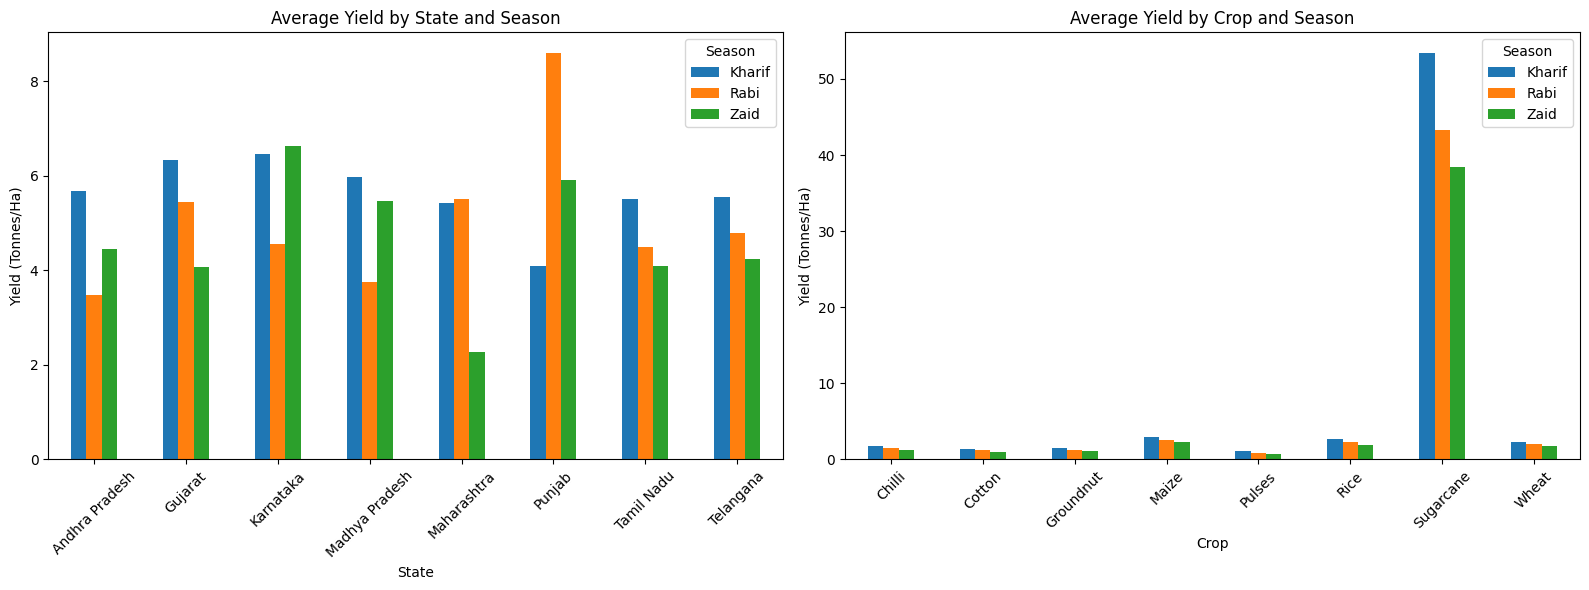

In [97]:
# Compare seasonal yield patterns across states and crops

season_order = ["Kharif", "Rabi", "Zaid"]

# Average yield by state and season
state_season = (
    df.groupby(["State", "Season"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

# Average yield by crop and season
crop_season = (
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_yield = state_season.pivot(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha"
).reindex(columns=season_order)

crop_yield = crop_season.pivot(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha"
).reindex(columns=season_order)

state_yield.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Yield by State and Season")
axes[0].set_ylabel("Yield (Tonnes/Ha)")
axes[0].set_xlabel("State")
axes[0].tick_params(axis="x", rotation=45)

crop_yield.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Yield by Crop and Season")
axes[1].set_ylabel("Yield (Tonnes/Ha)")
axes[1].set_xlabel("Crop")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

* **Karnataka** has high yield in Kharif and Zaid seasons.
* **Punjab** has the highest yield in the Rabi season.
* **Sugarcane** has the highest yield among all crops.
* **Cotton and Pulses** have relatively low yields.
* Yield varies across **states, crops, and seasons**.


8. which irrigation type has more yield

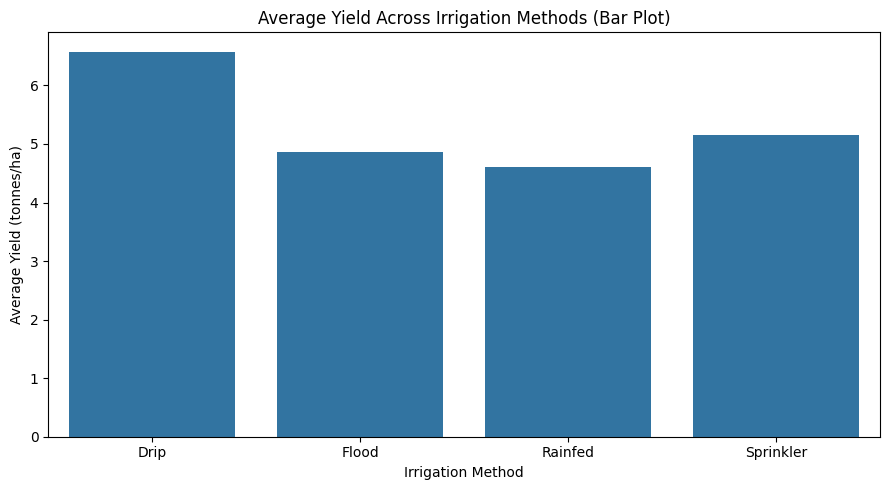

In [98]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

9. Are there unusual or unexpected seasonal patterns?

In [99]:
# Identify unusual or unexpected seasonal patterns

print("Seasonal profit:")
print(seasonal_summary["Profit_INR"].round(2))

print("\nSeasonal water usage:")
print(seasonal_summary["Water_Used_m3"].round(2))

print("\nHighest-yielding crop in each season:")
print(crop_yield.idxmax())

print("\nHighest-yielding state in each season:")
print(state_yield.idxmax())

# Compare each crop's yield across seasons
crop_change = crop_yield["Zaid"] - crop_yield["Kharif"]
print("\nChange in crop yield from Kharif to Zaid:")
print(crop_change.round(2))

print("\nUnexpected patterns:")
print("- Zaid has negative average profit despite using the most water.")
print("- Zaid has the lowest average yield and rainfall, but the highest temperature.")
print("- Sugarcane yield is substantially higher than all other crops.")
print("- Karnataka performs best in Zaid, while Punjab performs best in Rabi.")
print("- All crops show lower average yield in Zaid than in Kharif.")

Seasonal profit:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64

Seasonal water usage:
Season
Kharif    6102.20
Rabi      5846.99
Zaid      6419.89
Name: Water_Used_m3, dtype: float64

Highest-yielding crop in each season:
Season
Kharif    Sugarcane
Rabi      Sugarcane
Zaid      Sugarcane
dtype: str

Highest-yielding state in each season:
Season
Kharif    Karnataka
Rabi         Punjab
Zaid      Karnataka
dtype: str

Change in crop yield from Kharif to Zaid:
Crop
Chilli       -0.54
Cotton       -0.41
Groundnut    -0.45
Maize        -0.68
Pulses       -0.37
Rice         -0.80
Sugarcane   -15.04
Wheat        -0.51
dtype: float64

Unexpected patterns:
- Zaid has negative average profit despite using the most water.
- Zaid has the lowest average yield and rainfall, but the highest temperature.
- Sugarcane yield is substantially higher than all other crops.
- Karnataka performs best in Zaid, while Punjab performs best in Rabi.
- All crops 

10. What insights can be derived from the observed seasonal differences?

In [100]:
# Summary of insights from observed seasonal differences

best_yield_season = seasonal_summary["Yield_Tonnes_Ha"].idxmax()
best_profit_season = seasonal_summary["Profit_INR"].idxmax()
lowest_yield_season = seasonal_summary["Yield_Tonnes_Ha"].idxmin()
lowest_profit_season = seasonal_summary["Profit_INR"].idxmin()
highest_water_season = seasonal_summary["Water_Used_m3"].idxmax()

print("Key Insights")
print(f"- {best_yield_season} has the highest average yield "
    f"({seasonal_summary.loc[best_yield_season, 'Yield_Tonnes_Ha']:.2f} tonnes/ha).")
print(f"- {best_profit_season} is the most profitable season, with an average profit of "
    f"₹{seasonal_summary.loc[best_profit_season, 'Profit_INR']:,.2f}.")
print(f"- {lowest_yield_season} has the lowest average yield "
    f"({seasonal_summary.loc[lowest_yield_season, 'Yield_Tonnes_Ha']:.2f} tonnes/ha).")
print(f"- {lowest_profit_season} has the lowest average profit, including a negative average profit.")
print(f"- {highest_water_season} uses the most water, but does not achieve the highest yield.")
print("- Kharif benefits from higher rainfall and soil moisture, supporting better yields and profits.")
print("- Zaid has higher temperatures, lower rainfall and soil moisture, resulting in lower yields.")
print("- Sugarcane has the highest yield in every season, while all crops perform best in Kharif.")
print("- Punjab performs best in Rabi, while Karnataka performs best in Zaid.")
print("- Seasonal conditions strongly influence agricultural productivity and profitability.")


Key Insights
- Kharif has the highest average yield (5.63 tonnes/ha).
- Kharif is the most profitable season, with an average profit of ₹178,914.65.
- Zaid has the lowest average yield (4.64 tonnes/ha).
- Zaid has the lowest average profit, including a negative average profit.
- Zaid uses the most water, but does not achieve the highest yield.
- Kharif benefits from higher rainfall and soil moisture, supporting better yields and profits.
- Zaid has higher temperatures, lower rainfall and soil moisture, resulting in lower yields.
- Sugarcane has the highest yield in every season, while all crops perform best in Kharif.
- Punjab performs best in Rabi, while Karnataka performs best in Zaid.
- Seasonal conditions strongly influence agricultural productivity and profitability.
